### **Imports**

In [106]:
import pandas as pd
import numpy as np
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

### **Importing and Merging the Data Sets**

In [123]:
player_stats_all = pd.read_csv('players.csv')
player_stats_filter = pd.read_csv('player_stats.csv')
player_value = pd.read_csv('squads_and_players.csv')
merged_players_data = pd.merge(player_value, player_stats_filter, on=['player_id', 'team_id'], how='inner', suffixes=('_stats', '_value'))

# Select the required columns. Using the corrected market value column name.
player_market_value_df = merged_players_data[['player_id', 'team_id', 'player_name_stats', 'market_value_eur', 'position_stats']]

# Rename columns for clarity as requested by the user
player_market_value_df = player_market_value_df.rename(columns={'player_name_stats': 'player_name', 'market_value_eur': 'value', 'position_stats': 'position'})

display(player_market_value_df.head())

,player_id,team_id,player_name,value,position
0,1,1,José Raúl Rangel,8933646,GK
1,2,1,Jorge Eduardo Sanchez,24628639,DEF
2,3,1,César Jasib Montes,10912552,DEF
3,4,1,Edson Omar Alvarez,10875943,DEF
4,5,1,Johan Felipe Vasquez,18265363,DEF


In [108]:
#remove the middle name and accents in order to merge with the stats dataset
def remove_middle_name(full_name):
    parts = str(full_name).split()
    if len(parts) > 2:
        return parts[0] + ' ' + parts[-1]
    return full_name
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

player_market_value_df['player_name'] = player_market_value_df['player_name'].apply(remove_middle_name)
player_market_value_df['player_name'] = player_market_value_df['player_name'].apply(remove_accents)

display(player_market_value_df.head())

,player_id,team_id,player_name,value,position
0,1,1,Jose Rangel,8933646,GK
1,2,1,Jorge Sanchez,24628639,DEF
2,3,1,Cesar Montes,10912552,DEF
3,4,1,Edson Alvarez,10875943,DEF
4,5,1,Johan Vasquez,18265363,DEF


In [109]:
# Apply the same cleaning functions to player_stats_all['player']
player_stats_all['player'] = player_stats_all['player'].apply(remove_middle_name)
player_stats_all['player'] = player_stats_all['player'].apply(remove_accents)

# Rename the 'player' column in player_stats_all to 'player_name' for merging
player_stats_all = player_stats_all.rename(columns={'player': 'player_name'})

#Drop player position in this dataframe since the other dataframe has a more accurate position column
player_stats_all = player_stats_all.drop(columns=['position'])

In [110]:
player_df = pd.merge(
    player_market_value_df,
    player_stats_all,
    on='player_name',
    how='left'
)
player_df = player_df.drop(columns = ['player_id', 'team_id'])
model_results = pd.DataFrame(columns = ['Position', 'MAE', 'RMSE','R2'])

### **Cleaning**

In [111]:
goalkeepers_df = player_df[player_df['position'] == 'GK']
goalkeeper_features = [
    # Player context
    'player_name',
    'team',
    'age',

    # Goalkeeper playing time
    'gk_minutes',

    # Shot stopping
    'gk_goals_against_per90',
    'gk_shots_on_target_against',
    'gk_saves',
    'gk_save_pct',

    # Results and clean sheets
    'gk_clean_sheets',

    # Penalty performance
    'gk_pens_allowed',
    'gk_pens_saved',

    # Target value
    'value'
]
goalkeepers_df = goalkeepers_df[goalkeeper_features]


#drop goalkeepers with no games played
goalkeepers_df = goalkeepers_df.dropna(subset=['gk_minutes'])

#fill gk_save_pct with median for the gks with null
goalkeepers_df['gk_save_pct'] = goalkeepers_df['gk_save_pct'].fillna(goalkeepers_df['gk_save_pct'].median())

In [112]:
#Linear Regression baseline for goalkeepers
gk_X = goalkeepers_df.drop(columns=['player_name', 'value'])
gk_y = goalkeepers_df['value']
X_train, X_test, y_train, y_test = train_test_split(gk_X, gk_y, test_size=0.2, random_state=42)

#GK numerical and categorical features
gk_categorical_features = gk_X.select_dtypes(include=['object']).columns
gk_numerical_features = gk_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
gk_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
gk_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
gk_preprocessor = ColumnTransformer(
    transformers=[
        ('num', gk_numerical_pipe, gk_numerical_features),
        ('cat', gk_categorical_pipe, gk_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
gk_pipe = Pipeline([
    ('preprocessor', gk_preprocessor),
    ('regressor', LinearRegression())
])

gk_pipe.fit(X_train, y_train)
gk_pred = gk_pipe.predict(X_test)
gk_mae = mean_absolute_error(y_test, gk_pred)
gk_rmse = root_mean_squared_error(y_test, gk_pred)
gk_r2 = gk_pipe.score(X_test, y_test)

#Append to results df
model_results.loc[len(model_results)] = ['Goalkeeper', gk_mae,gk_rmse, gk_r2]

In [113]:
defenders_df = player_df[player_df['position'] == 'DEF']
defender_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Defensive performance
    'interceptions',
    'tackles_won',
    'fouls',
    'cards_yellow',
    'cards_red',

    # Team performance
    'plus_minus_per90',

    # Offensive contribution
    'goals',
    'assists',
    'crosses',

    #Target value
    'value'
]
#parse for only defender features
defenders_df = defenders_df[defender_features]

#drop any values that are null
defenders_df = defenders_df.dropna(subset = ['minutes_90s'])

In [114]:
forwards_df = player_df[player_df['position'] == 'FWD']
forward_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Scoring
    'goals_pens_per90',

    # Chance creation
    'assists_per90',

    # Shooting
    'shots_per90',
    'shots_on_target_per90',

    # Attacking activity
    'offsides',
    'fouled',
    'crosses',

    # Team performance
    'plus_minus_per90',

    # Target value
    'value'
]
#parse for only forward_features
forwards_df = forwards_df[forward_features]

#parse out any nulls
forwards_df = forwards_df.dropna(subset = ['minutes_90s'])

In [115]:
midfielders_df = player_df[player_df['position'] == 'MID']
midfielder_features = [
    # Player context
    'player_name',
    'age',
    'team',
    'minutes_90s',

    # Attacking contribution
    'goals_per90',
    'assists_per90',
    'shots_per90',
    'shots_on_target_per90',
    'crosses',

    # Defensive and possession-related contribution
    'interceptions',
    'tackles_won',
    'fouls',
    'fouled',

    # Team performance
    'plus_minus_per90',

    # Target value
    'value'
]
#parse for only midfielder_features
midfielders_df = midfielders_df[midfielder_features]
#parse out null values
midfielders_df = midfielders_df.dropna(subset = ['minutes_90s'])

### **Outlier Check**

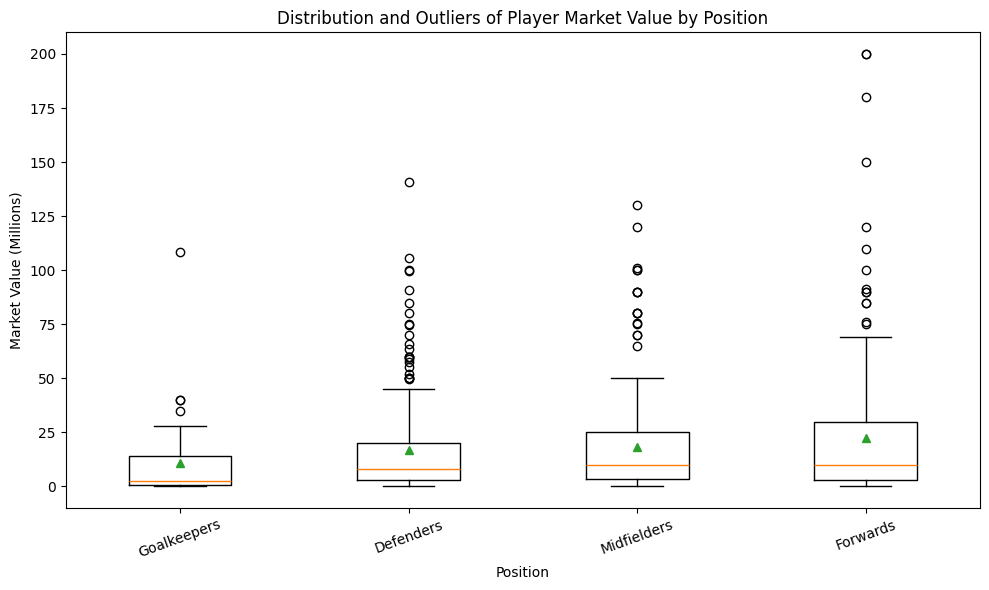

In [116]:
# @title
#positional values in millions
position_data = [
    goalkeepers_df['value'].dropna() / 1_000_000,
    defenders_df['value'].dropna() / 1_000_000,
    midfielders_df['value'].dropna() / 1_000_000,
    forwards_df['value'].dropna() / 1_000_000
]

plt.figure(figsize=(10, 6))

#boxplots for each position
plt.boxplot(
    position_data,
    tick_labels=[
        'Goalkeepers',
        'Defenders',
        'Midfielders',
        'Forwards'
    ],
    showmeans=True
)

plt.title('Distribution and Outliers of Player Market Value by Position')
plt.xlabel('Position')
plt.ylabel('Market Value (Millions)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [124]:
#Function that removes outliers for a given dataframe and column value
def remove_outliers_iqr(df, column='value'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ].copy()

    return cleaned_df

#Applying this onto the positional dataframes
goalkeepers_df = remove_outliers_iqr(goalkeepers_df)
defenders_df = remove_outliers_iqr(defenders_df)
midfielders_df = remove_outliers_iqr(midfielders_df)
forwards_df = remove_outliers_iqr(forwards_df)

### **Model Creation**

In [118]:
#Linear Regression baseline for defenders
defender_X = defenders_df.drop(columns=['player_name', 'value'])
defender_y = defenders_df['value']
X_train, X_test, y_train, y_test = train_test_split(defender_X, defender_y, test_size=0.2, random_state=42)

#Defender numerical and categorical features
defender_categorical_features = defender_X.select_dtypes(include=['object']).columns
defender_numerical_features = defender_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
defender_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
defender_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
defender_preprocessor = ColumnTransformer(
    transformers=[
        ('num', defender_numerical_pipe, defender_numerical_features),
        ('cat', defender_categorical_pipe, defender_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
defender_pipe = Pipeline([
    ('preprocessor', defender_preprocessor),
    ('regressor', LinearRegression())
])
defender_pipe.fit(X_train, y_train)
defender_pred = defender_pipe.predict(X_test)
defender_mae = mean_absolute_error(y_test, defender_pred)
defender_r2 = defender_pipe.score(X_test, y_test)
defender_rmse = root_mean_squared_error(y_test, defender_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Defender', defender_mae, defender_rmse, defender_r2]

In [119]:
#Train/test split for forwards data
forward_X = forwards_df.drop(columns=['player_name', 'value'])
forward_y = forwards_df['value']
X_train, X_test, y_train, y_test = train_test_split(forward_X, forward_y, test_size=0.2, random_state=42)

#Forward numerical and categorical features
forward_categorical_features = forward_X.select_dtypes(include=['object']).columns
forward_numerical_features = forward_X.select_dtypes(include=['int64', 'float64']).columns

#Numerical pipeline
forward_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical pipeline
forward_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
forward_preprocessor = ColumnTransformer(
    transformers=[
        ('num', forward_numerical_pipe, forward_numerical_features),
        ('cat', forward_categorical_pipe, forward_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
forward_pipe = Pipeline([
    ('preprocessor', forward_preprocessor),
    ('regressor', LinearRegression())
])

forward_pipe.fit(X_train, y_train)
forward_pred = forward_pipe.predict(X_test)

forward_pipe.fit(X_train, y_train)
forward_pred = forward_pipe.predict(X_test)
forward_mae = mean_absolute_error(y_test, forward_pred)
forward_r2 = forward_pipe.score(X_test, y_test)
forward_rmse = root_mean_squared_error(y_test, forward_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Forward', forward_mae, forward_rmse, forward_r2]

In [120]:
#Train/test split for midfielders data
midfielder_X = midfielders_df.drop(columns=['player_name', 'value'])
midfielder_y = midfielders_df['value']
X_train, X_test, y_train, y_test = train_test_split(midfielder_X, midfielder_y, test_size=0.2, random_state=42)

#Midfielder numerical and categorical features
midfielder_numerical_features = midfielder_X.select_dtypes(include=['int64', 'float64']).columns
midfielder_categorical_features = midfielder_X.select_dtypes(include=['object']).columns

#Numerical Pipeline
midfielder_numerical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

#Categorical Pipeline
midfielder_categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#Preprocessor
midfielder_preprocessor = ColumnTransformer(
    transformers=[
        ('num', midfielder_numerical_pipe, midfielder_numerical_features),
        ('cat', midfielder_categorical_pipe, midfielder_categorical_features)
    ]
)

#Pipeline with preprocessor and Linear Regression
midfielder_pipe = Pipeline([
    ('preprocessor', midfielder_preprocessor),
    ('regressor', LinearRegression())
])
midfielder_pipe.fit(X_train, y_train)
midfielder_pred = midfielder_pipe.predict(X_test)
midfielder_mae = mean_absolute_error(y_test, midfielder_pred)
midfielder_r2 = midfielder_pipe.score(X_test, y_test)
midfielder_rmse = root_mean_squared_error(y_test, midfielder_pred)

#Append to results df
model_results.loc[len(model_results)] = ['Midfielder', midfielder_mae, midfielder_rmse, midfielder_r2]

### **Analysis**

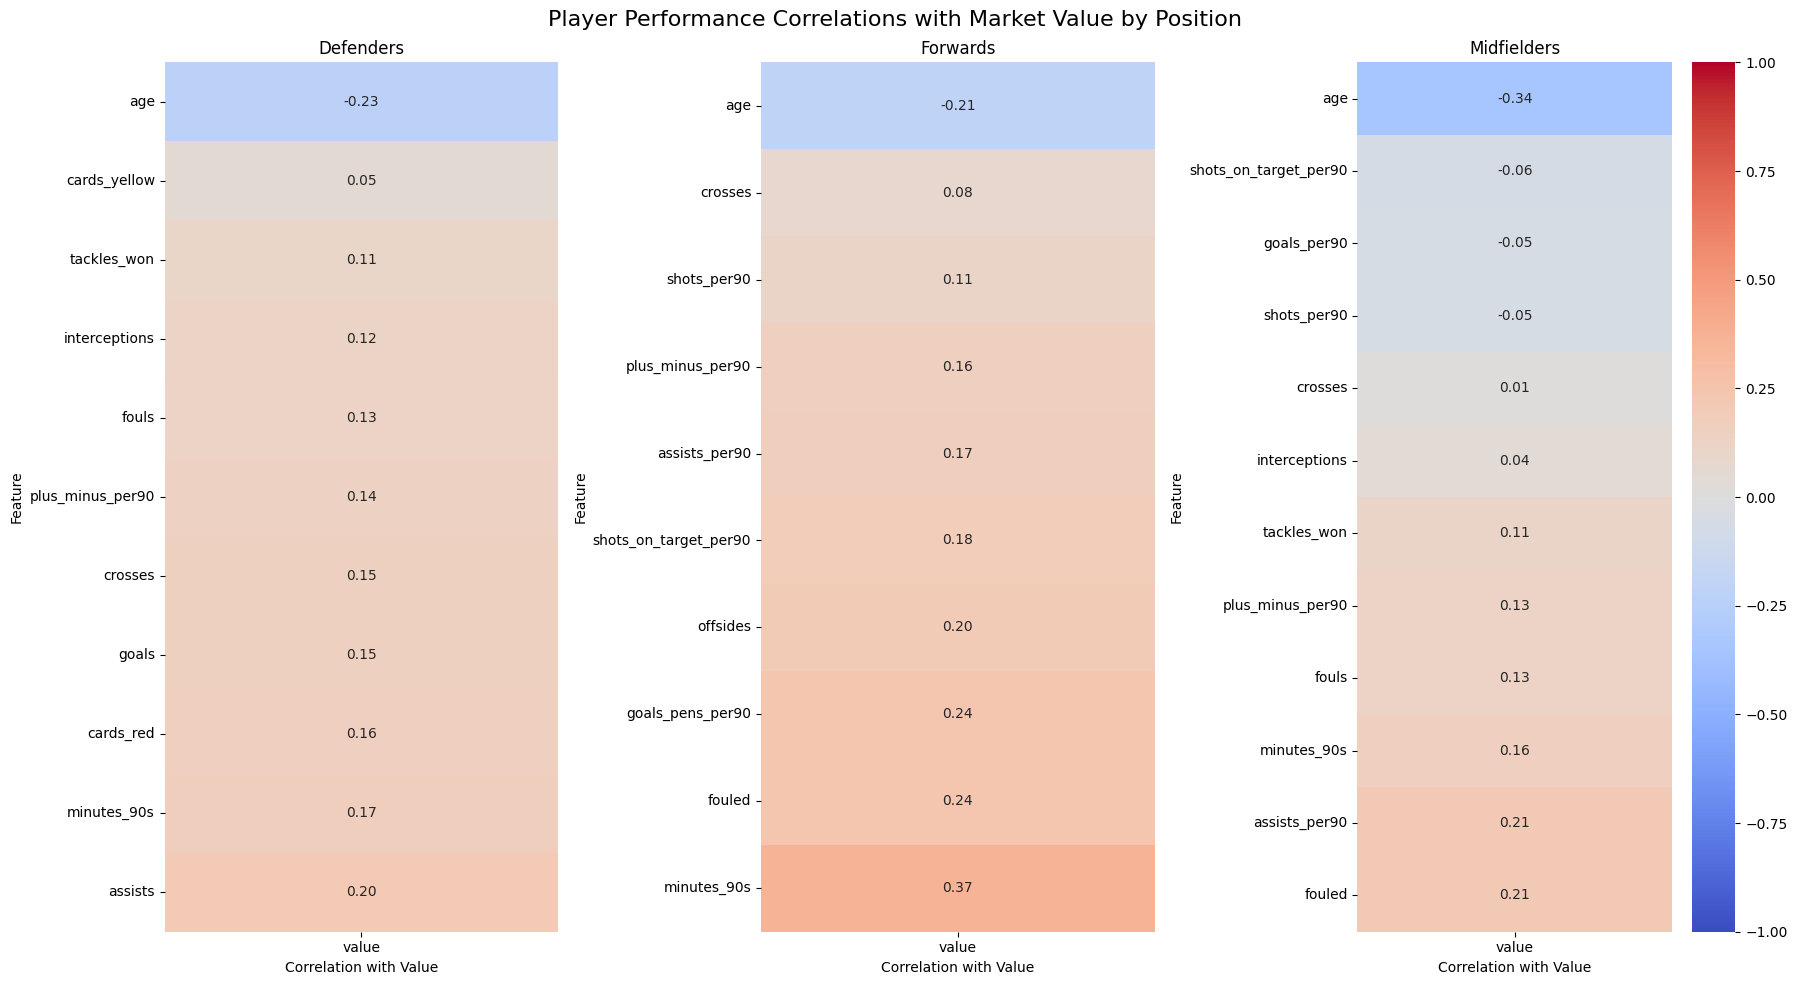

In [121]:
# @title
#Plotting heatmaps for the different positions
defender_corr = defenders_df.corr(numeric_only=True)['value'].drop('value').sort_values()
forward_corr = forwards_df.corr(numeric_only=True)['value'].drop('value').sort_values()
midfielder_corr = midfielders_df.corr(numeric_only=True)['value'].drop('value').sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 10))

#defender heatmap
sns.heatmap(
    defender_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[0],
    cbar=False
)
axes[0].set_title('Defenders')
axes[0].set_xlabel('Correlation with Value')
axes[0].set_ylabel('Feature')

#forward heatmap
sns.heatmap(
    forward_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[1],
    cbar=False
)
axes[1].set_title('Forwards')
axes[1].set_xlabel('Correlation with Value')
axes[1].set_ylabel('Feature')

#midfielder heatmap
sns.heatmap(
    midfielder_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=axes[2]
)
axes[2].set_title('Midfielders')
axes[2].set_xlabel('Correlation with Value')
axes[2].set_ylabel('Feature')

fig.suptitle(
    'Player Performance Correlations with Market Value by Position',
    fontsize=16
)

plt.tight_layout()
plt.show()

The heatmaps above show how individual Worldcup performance stats correlate with player market value.

One important thing to note is that all three graphs have age as the most negatively correlated stat, suggesting that younger players tend to earn more money than older players. This makes sense because younger players have better fitness and are closer to their prime.

Furthemore, minutes played per 90 seconds are amongst the higher correlated features, suggesting that players who have more field time earn more. This sounds reasonable because players with high playing time tend to have stronger technical abilities, knowledge, and trust from management, all strong factors for higher market values.

Surprisingly, position based statistics alone don't have a high correlation with market value. This suggests that market values heavily rely on a plethora of stats. As a result, I have chosen to use **Multiple Linear Regression** as a baseline model because it can evaluate a multitude of player attributes while remaining interpretable.



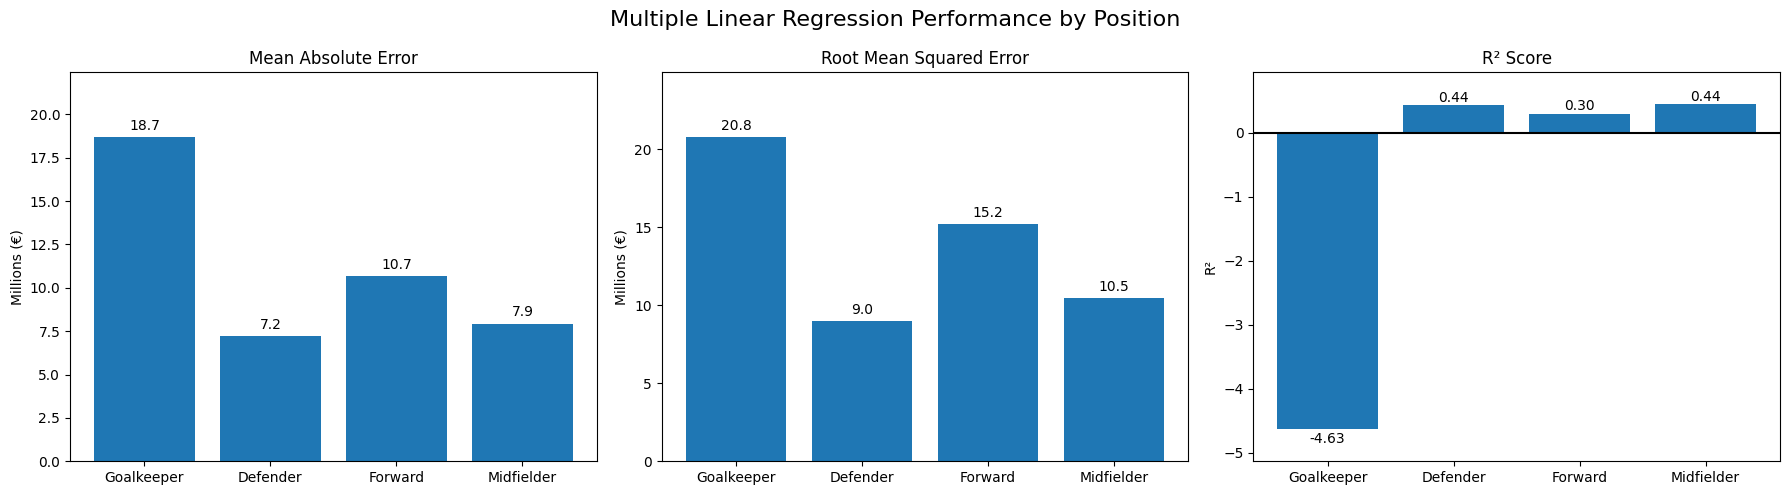

In [122]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convert to millions
mae = model_results['MAE'] / 1_000_000
rmse = model_results['RMSE'] / 1_000_000
r2 = model_results['R2']

###########################
# MAE
###########################

bars = axes[0].bar(model_results['Position'], mae)

axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('Millions (€)')
axes[0].set_ylim(0, mae.max()*1.2)

axes[0].bar_label(
    bars,
    labels=[f'{x:.1f}' for x in mae],
    padding=3
)

###########################
# RMSE
###########################

bars = axes[1].bar(model_results['Position'], rmse)

axes[1].set_title('Root Mean Squared Error')
axes[1].set_ylabel('Millions (€)')
axes[1].set_ylim(0, rmse.max()*1.2)

axes[1].bar_label(
    bars,
    labels=[f'{x:.1f}' for x in rmse],
    padding=3
)

###########################
# R²
###########################

bars = axes[2].bar(model_results['Position'], r2)

axes[2].axhline(0, color='black')
axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')

axes[2].set_ylim(
    r2.min()-0.5,
    r2.max()+0.5
)

for bar, value in zip(bars, r2):
    if value >= 0:
        axes[2].text(
            bar.get_x()+bar.get_width()/2,
            value+0.05,
            f'{value:.2f}',
            ha='center'
        )
    else:
        axes[2].text(
            bar.get_x()+bar.get_width()/2,
            value-0.05,
            f'{value:.2f}',
            ha='center',
            va='top'
        )

fig.suptitle(
    'Multiple Linear Regression Performance by Position',
    fontsize=16
)

plt.tight_layout()
plt.show()

The table above reveals the mean absolute error and r2 score for the  multiple linear regression models created for each position. Mean absolute error was picked as the primary model performance metric because it measures the average error in euros between the predicted and true market values, making it easy to understand. RMSE was used as a secondary metric to penalize **outliers** and tests whether MAE was a good primary metric.

The most important result to note is that the goalkeeper data got an R2 score of -4.63. This makes sense because after cleaning the data, only 39 goalies were chosen for modeling. Such a small sample size will produce useless models. As a result, future models will not include goalkeeper data.

The remaining models have a relatively medium R2 value. This makes sense because the dataset reflects player stats during a month long tournament and doesn't include key features that play a role in player cost. Lack of stats and time makes Linear Regression have a performance cap. Further modeling may be able to improve these metrics.

Another interesting observation is that the MAE and RMSE graphs for defenders, midfielders, and forwards look the same, except the RMSE values are slightly larger. The difference in magnitude makes sense because RMSE squares before averaging, making the final results larger. The more important thing is that the relative performance across position stayed about the same. This suggests that Linear Regression was able to handle outliers in the dataset or that there aren't enough outliers to skew the data.

